Order: ['Higher Resolution', 'Lower Resolution', 'Crude Downsample', 'Thick Slice', 'In-Plane Coarsening', 'Reduced SNR', 'Rigid Jitter']
Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/compare_hard_dice.png
Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/compare_hard_dice.png


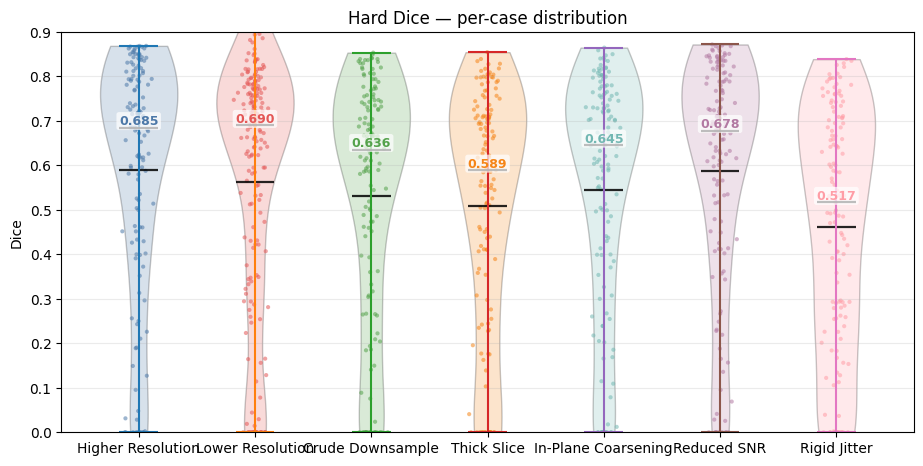

Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/compare_hd.png


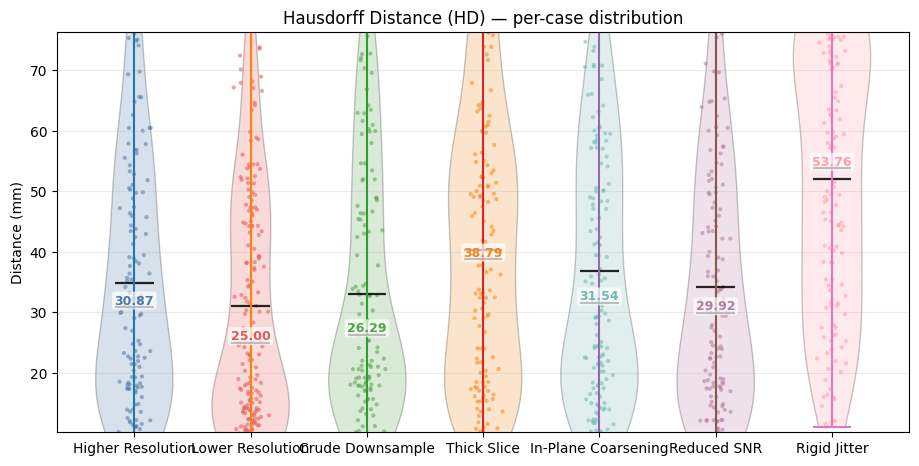

Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/compare_assd.png


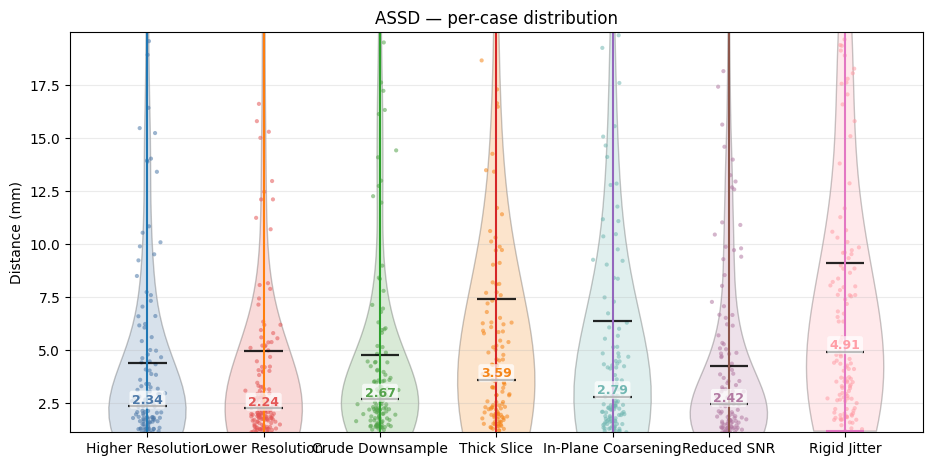

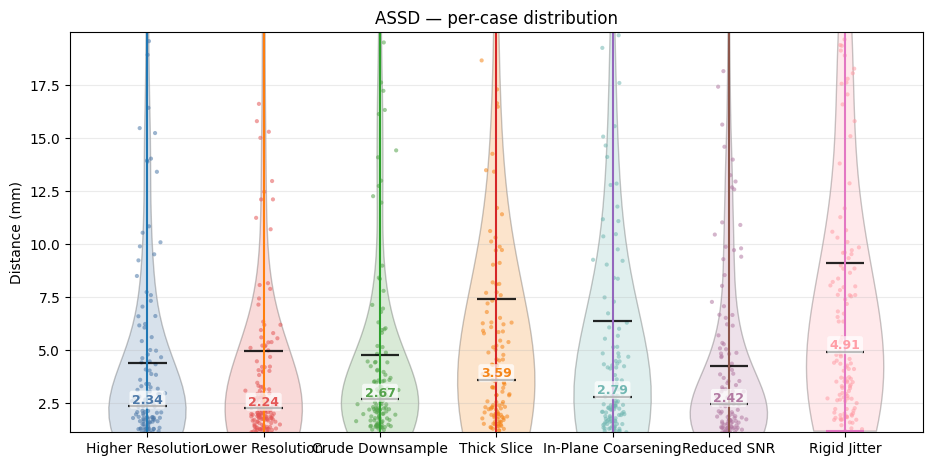

In [3]:
# === Multi-dataset comparison violins (Hard Dice, HD, ASSD) ===
from pathlib import Path
import csv, numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Any, Tuple, Optional

# ---------------------- styling ----------------------
PALETTE = ["#4C78A8", "#E45756", "#54A24B", "#F58518", "#72B7B2",
           "#B279A2", "#FF9DA6", "#9D7760", "#59A14F", "#EDC948"]
POINT_ALPHA, POINT_SIZE = 0.55, 9
VIOLIN_ALPHA, EDGE_ALPHA = 0.22, 0.35
JITTER_WIDTH, SEED = 0.10, 7
_rng = np.random.default_rng(SEED)

def _dropna(a):
    a = np.asarray(a, float); return a[~np.isnan(a)]

def _robust_limits(arr, p=(5,95), clamp01=False, min_span=1e-6):
    arr = _dropna(np.asarray(arr, float))
    if arr.size == 0:
        return (0.0, 1.0) if clamp01 else (0.0, 1.0)
    lo, hi = np.percentile(arr, p[0]), np.percentile(arr, p[1])
    if clamp01:
        lo, hi = max(0.0, lo), min(1.0, max(0.9, hi))
    if hi - lo < min_span: hi = lo + min_span
    return float(lo), float(hi)

def _beeswarm_x(center: float, n: int, spread: float) -> np.ndarray:
    if n == 0: return np.array([])
    return center + _rng.normal(0.0, spread, size=n)

# ---------------------- IO ----------------------
def load_rows_from_csv(csv_path: Path, fallback_tag="unknown") -> List[Dict[str, Any]]:
    with open(csv_path, newline="") as f:
        rd = csv.DictReader(f)
        cols = rd.fieldnames or []
        hard_col = next((c for c in cols if c=="hard_dice" or c.startswith("hard_dice_at_")),
                        "hard_dice_at_0.50")
        rows = []
        for r in rd:
            rows.append({
                "dataset_tag": (r.get("dataset_tag") or fallback_tag).strip(),
                "hard_dice": float(r.get(hard_col, "nan")),
                "hd":   float(r.get("hd", "nan")),
                "assd": float(r.get("assd", "nan")),
            })
    return rows

def build_datasets(items: List[Tuple[Path, str]]) -> Tuple[Dict[str, Dict[str, Any]], List[str]]:
    """items: list of (csv_path, label). Returns (datasets, tag_order)."""
    datasets: Dict[str, Dict[str, Any]] = {}
    tag_order: List[str] = []
    for p, label in items:
        rows = load_rows_from_csv(p, fallback_tag=label or p.stem)
        if not rows:
            print(f"WARNING: no rows in {p}")
            continue
        tag = label or (rows[0]["dataset_tag"] if rows else p.stem)
        if tag not in datasets:
            datasets[tag] = {"rows": [], "source_paths": []}
            tag_order.append(tag)  # preserve order from CSV_ITEMS
        datasets[tag]["rows"].extend(rows)
        datasets[tag]["source_paths"].append(str(p))
    return datasets, tag_order

# ---------------------- plotting ----------------------
def violin_compare(metric_key: str, title: str, ylabel: str, save_name: str,
                   datasets: Dict[str, Dict[str, Any]],
                   clamp01=False, units=None,
                   xtick_label_map: Dict[str,str]=None,
                   tag_order: List[str]=None,
                   value_format: Optional[str]=None):
    tags = tag_order if tag_order else list(datasets.keys())
    arrs = [ _dropna([r[metric_key] for r in datasets[t]["rows"]]) for t in tags ]
    fmt = value_format if value_format else ("{:.3f}" if clamp01 else "{:.2f}")

    plt.style.use("default")
    fig, ax = plt.subplots(figsize=(11, 5.2))

    base_x = np.arange(1, len(tags)+1, dtype=float)
    width = 0.7

    # violins + points
    for i, (vals, tag) in enumerate(zip(arrs, tags)):
        color = PALETTE[i % len(PALETTE)]
        pos = base_x[i]
        parts = ax.violinplot([vals if vals.size else np.array([np.nan])],
                              positions=[pos], widths=width*0.95,
                              showmeans=True, showmedians=True)
        for b in parts.get('bodies', []):
            b.set_facecolor(color)
            b.set_edgecolor((0,0,0,EDGE_ALPHA))
            b.set_alpha(VIOLIN_ALPHA)
        if 'cmeans' in parts:
            parts['cmeans'].set_linewidth(1.6); parts['cmeans'].set_color((0,0,0,0.85))
        if 'cmedians' in parts:
            parts['cmedians'].set_linewidth(1.6); parts['cmedians'].set_color((0,0,0,0.85))
        if vals.size:
            xs = _beeswarm_x(pos, len(vals), width*0.08)
            ax.scatter(xs, vals, s=POINT_SIZE, alpha=POINT_ALPHA, color=color, edgecolor='none')
            median_val = float(np.median(vals))
            ax.text(
                pos, median_val, fmt.format(median_val),
                ha="center", va="bottom", fontsize=9, fontweight="bold", color=color,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
                zorder=6
            )

    # axes & limits
    ax.set_xticks(base_x)
    ax.set_xticklabels([xtick_label_map.get(t, t) if xtick_label_map else t for t in tags])
    ax.set_title(title)
    ax.set_ylabel(ylabel if units is None else f"{ylabel} ({units})")
    ax.grid(True, axis='y', alpha=0.25)

    flat = np.concatenate([v for v in arrs if v.size]) if any(v.size for v in arrs) else np.array([])
    if flat.size:
        lo, hi = _robust_limits(flat, clamp01=clamp01)
        ax.set_ylim(lo, hi)

    # save next to the first dataset (in requested order)
    out_dir = Path(datasets[tags[0]]["source_paths"][0]).parent if datasets else Path(".")
    out_path = out_dir / save_name
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    print(f"Saved -> {out_path}")
    plt.show()
    return fig

# ===================== EDIT THESE, THEN RUN CELL =====================
CSV_ITEMS = [
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_hires_metrics_20251111_130301.csv"), "Higher Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_143340.csv"), "Lower Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_crude_metrics_20251111_155445.csv"), "Crude Downsample"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_161029.csv"), "Thick Slice"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_InPlane_metrics_20251111_163449.csv"), "In-Plane Coarsening"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_181436.csv"), "Reduced SNR"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_172142.csv"), "Rigid Jitter")
    # Add more (Path(...), "Your Label") here...
]

# Optional: pretty axis labels (if omitted, labels from CSV_ITEMS are used)
XTICK_LABELS = {
    "Higher Resolution": "Higher Resolution",
    "Lower Resolution":  "Lower Resolution",
    "Crude Downsample":  "Crude Downsample",
    "Thick Slice":       "Thick Slice",
}

# Build data (UNPACK the tuple!)
datasets, tag_order = build_datasets(CSV_ITEMS)
print("Order:", tag_order)

# 1) Hard Dice
violin_compare(
    "hard_dice",
    title="Hard Dice — per-case distribution",
    ylabel="Dice", clamp01=True,
    save_name="compare_hard_dice.png",
    datasets=datasets,
    xtick_label_map=XTICK_LABELS,
    tag_order=tag_order,
    value_format="{:.3f}"
)

# 2) Hausdorff Distance (HD)
violin_compare(
    "hd",
    title="Hausdorff Distance (HD) — per-case distribution",
    ylabel="Distance", units="mm",
    save_name="compare_hd.png",
    datasets=datasets,
    xtick_label_map=XTICK_LABELS,
    tag_order=tag_order,
    value_format="{:.2f}"
)

# 3) ASSD
violin_compare(
    "assd",
    title="ASSD — per-case distribution",
    ylabel="Distance", units="mm",
    save_name="compare_assd.png",
    datasets=datasets,
    xtick_label_map=XTICK_LABELS,
    tag_order=tag_order,
    value_format="{:.2f}"
)


In [ ]:
/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_InPlane_metrics_20251111_163449.csv